In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json

In [2]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/DDM_T1_varyloss.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

In [3]:

# Keep T1 AA4.1 in the data and remove the rest 

# Change column name to match the other dataframe
df_new1 = df_new.rename(columns = {'Age at S1K':'age.at.S1K'})
df_ont1 = df_ont.rename(columns = {'T1 AA4.1+_total':'total_T1_AA4.1+', 'MZ_total':'total_MZ'})

df_T1counts_Nfd = df_new1.filter(items=['age.at.S1K', 'total_T1_AA4.1+', 'total_MZ'])
df_T1counts_ont = df_ont1.filter(items=['age.at.S1K', 'total_T1_AA4.1+', 'total_MZ'])
# print(df_T1counts_Nfd.head(10))
# print(df_T1counts_ont.head(10))

# combine in one dataframe
total_T1counts = pd.concat([df_T1counts_Nfd, df_T1counts_ont])
total_T1counts = total_T1counts.sort_values(by='age.at.S1K')
print(total_T1counts.head(10))

#save the data to a csv file

# df_T1counts_Nfd.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T1counts_Nfd.csv', index=False)
# df_T1counts_ont.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T1counts_ont.csv', index=False)


# Creating a list to use as an input in Stan model

data = {'numobs': len(total_T1counts['age.at.S1K']), 
        'numsolve' : total_T1counts['age.at.S1K'].tolist(),
        'numT1counts' : total_T1counts['total_T1_AA4.1+'].tolist(),
        'time_pred' : np.array(np.arange(10,731,1)).tolist(),
        'num_pred' : len(np.array(np.arange(10,731,1)))
}

json_string = json.dumps(data)

file_path1 = '/home/apoorva/Desktop/work/MZ_analysis/data/data_T1fits.json'
with open(file_path1, 'wb') as json_file:
    json_file.write(json_string.encode())

   age.at.S1K  total_T1_AA4.1+       total_MZ
2          11     3.302817e+06   18873.238938
3          11     2.677656e+06   11941.171604
1          11     3.223400e+06    7450.000000
0          11     4.145272e+06   12058.666667
6          14     9.934749e+06   55375.823430
7          14     9.792409e+06  102645.316456
4          14     6.970682e+06  173580.615385
5          14     8.923469e+06   65914.813614
8          14     8.129739e+06  152588.316151
9          18     8.048254e+06  120475.287009


In [4]:
# # Keep T1 AA4.1 in the data and remove the rest 

# df_T1counts_Nfd = df_new.filter(items=['Lamis.ID', 'Days postBMT', 'Age at S1K', 'total_T1_AA4.1+'])
# df_T1counts_ont = df_ont.filter(items=['mouse', 'age.at.S1K', 'T1 AA4.1+_total'])
# print(df_T1counts_Nfd.head(10))
# print(df_T1counts_ont.head(10))

# #save the data to a csv file

# df_T1counts_Nfd.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T1counts_Nfd.csv', index=False)
# df_T1counts_ont.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T1counts_ont.csv', index=False)



In [5]:
# data time points
data_time = total_T1counts['age.at.S1K'].values

# Create a dataframe with unique age at S1K values
dfunique = total_T1counts.drop_duplicates(subset='age.at.S1K', keep='first')
dfunique = dfunique.sort_values(by='age.at.S1K')
dfunique = dfunique.reset_index(drop=True)

# unique time points in data
solve_time = dfunique['age.at.S1K'].values
# solve_ageatbmt = dfunique['Age at BMT'].values

# create index map of data time to solve time for Nfd
time_index_map = np.zeros(len(data_time), dtype=int)
for i, t in enumerate(solve_time):
    time_index_map[data_time == t] = i+1

print(time_index_map)
#time sequence for predictions specific to agebins within the data
time_pred1_solve= np.array(np.arange(11, 750, 1))
# time_pred3_solve= np.array(np.arange(88, 750, 1))
# time_pred2_solve= np.array(np.arange(66, 750, 1))
# time_pred1_initial = 11.0
# time_pred3_bmt= 87.0
# time_pred2_bmt= 65.0

[ 1  1  1  1  2  2  2  2  2  3  3  3  3  4  4  5  5  5  5  5  5  6  6  6
  6  7  7  7  7  8  8  8  8  8  8  9  9 10 10 10 10 10 11 12 12 13 13 14
 14 14 14 15 15 16 17 18 19 20 21 22 23 24 25 26 26 27 28 29 30 31 32 33
 34 35 36 36 37 38 39 40 41 41 42 42]


In [6]:
# Create a dataframe with unique age at S1K values for ontogeny data
# data time points
data_time_ont = df_T1counts_ont['age.at.S1K'].values

# Create a dataframe with unique age at S1K values
df_unique_ont = df_T1counts_ont.drop_duplicates(subset='age.at.S1K', keep='first')
df_unique_ont = df_unique_ont.sort_values(by='age.at.S1K')
df_unique_ont = df_unique_ont.reset_index(drop=True)

# unique time points in data
solve_time_ont = df_unique_ont['age.at.S1K'].values
# solve_ageatbmt = dfunique['Age at BMT'].values

# create index map of data time to solve time for Nfd
time_index_map_ont = np.zeros(len(data_time_ont), dtype=int)
for i, t in enumerate(solve_time_ont):
    time_index_map_ont[data_time_ont == t] = i+1

print(len(time_index_map_ont))
print(solve_time_ont)
print(data_time_ont)
print(len(np.array(df_T1counts_ont['total_MZ'])))
#time sequence for predictions specific to agebins within the data
time_pred_solve= np.array(np.arange(11, 190, 1))

62
[ 11  14  18  19  20  22  23  24  25  26  27  28  29  31  33  36  39  43
  53  57  71 113 152]
[ 11  11  11  11  14  14  14  14  14  18  18  18  18  19  19  20  20  20
  20  20  20  22  22  22  22  23  23  23  23  24  24  24  24  24  24  25
  25  26  26  26  26  26  27  28  28  29  29  31  31  31  31  33  33  36
  39  43  53  57  71 113 152 152]
62


In [7]:
data_mz_ontogenyT1={"numobs" : len(df_T1counts_ont['age.at.S1K']),  # Number of donor fraction observations
      "numsolve" : len(solve_time_ont),  # Number of unique time points in the data
      "data_time" : data_time_ont,
      "time_index_map" : time_index_map_ont,
      "solve_time" : solve_time_ont,
      "totalMZ" : np.array(df_T1counts_ont['total_MZ']),
      "time_pred1_solve" : time_pred_solve,
      "numpred" : len(time_pred_solve)}

# Export data to JSON
def numpy_array_encoder(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert numpy array to a list
    raise TypeError("Object of type {} is not JSON serializable".format(type(obj)))

# Serialize dictionary to JSON using custom encoder function
json_string = json.dumps(data_mz_ontogenyT1, default=numpy_array_encoder)

file_path= "/home/apoorva/Desktop/work/MZ_analysis/data/Mz_ontogenyT1.varyinginflux.json"
with open(file_path, "w") as json_file:  json_file.write(json_string)

print("Data saved to", file_path)

Data saved to /home/apoorva/Desktop/work/MZ_analysis/data/Mz_ontogenyT1.varyinginflux.json


In [8]:
#Binning the data for Nfd dataframe on equally sized aged bins based on age at BMT
from numpy import size

print(data_time)
print(solve_time)

[ 11  11  11  11  14  14  14  14  14  18  18  18  18  19  19  20  20  20
  20  20  20  22  22  22  22  23  23  23  23  24  24  24  24  24  24  25
  25  26  26  26  26  26  27  28  28  29  29  31  31  31  31  33  33  36
  39  43  53  57  59  62  69  71  76  88  88  92  95 102 109 113 119 123
 124 141 152 152 158 212 219 291 306 306 731 731]
[ 11  14  18  19  20  22  23  24  25  26  27  28  29  31  33  36  39  43
  53  57  59  62  69  71  76  88  92  95 102 109 113 119 123 124 141 152
 158 212 219 291 306 731]


In [9]:
# Creating a list to use as an input in Stan model

data_mz_ontogenyT1={"numobs" : len(total_T1counts['age.at.S1K']),  # Number of donor fraction observations
      "numsolve" : len(solve_time),  # Number of unique time points in the data
      "data_time" : data_time,
      "time_index_map" : time_index_map,
      "solve_time" : solve_time,
      "totalMZ" : np.array(total_T1counts['total_MZ']),
      "time_pred1_solve" : time_pred1_solve,
      "numpred" : len(time_pred1_solve)}

# Export data to JSON
def numpy_array_encoder(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert numpy array to a list
    raise TypeError("Object of type {} is not JSON serializable".format(type(obj)))

# Serialize dictionary to JSON using custom encoder function
json_string = json.dumps(data_mz_ontogenyT1, default=numpy_array_encoder)

file_path= "/home/apoorva/Desktop/work/MZ_analysis/data/newdata_mzontogenyT1.json"
with open(file_path, "w") as json_file:  json_file.write(json_string)

print("Data saved to", file_path)
  

Data saved to /home/apoorva/Desktop/work/MZ_analysis/data/newdata_mzontogenyT1.json


In [10]:
# Find M(42) and M(60) values
# print(data_neutral.MZ_counts_pred1[18])
print(np.mean(data_neutral.MZ_counts_pred1[18]))

2567670.5790960453


/tmp/ipykernel_3498136/1546301901.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


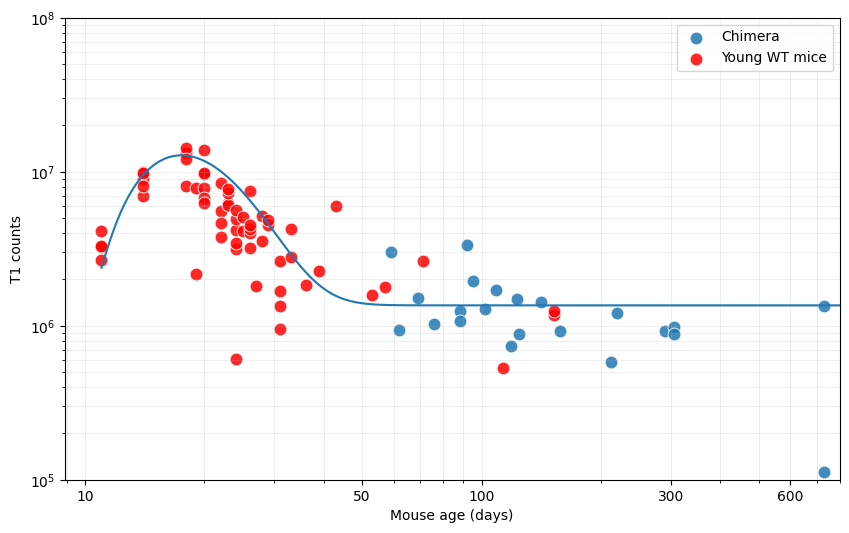

In [11]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    # # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    # return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    # theta_0 = np.exp(14.12)
    # nu = 0.264
    # # n = 1.96
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T1 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [12]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
def delta_dd(M):
    delta = np.mean(data_neutral.delta)
    size = np.mean(data_neutral.size_dens)
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi * P(t) + rho * M - delta_dd(M) * M
    return dMdt  # Ensure the return value matches the shape of M


# Define the parameters as array

# phi = data_neutral.phi  #Influx rate
# rho = data_neutral.rho  #Division rate

phi = 0.013 #Influx rate
rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [7450]

t_ev = np.arange(11, 750, 0.001)

sol = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol.y)

# sol = np.zeros((len(data_neutral.phi), len(t_ev)))
# for i in range(len(data_neutral.phi)):
#     result = solve_ivp(ode_function, [40, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
#     sol[i, :] = result.y[0]

# print(sol.shape)
# print(M0)



[[   7450.            7482.27235557    7514.56801706 ... 2508639.26897907
  2508639.28988026 2508639.31078076]]


/tmp/ipykernel_3498136/439309075.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


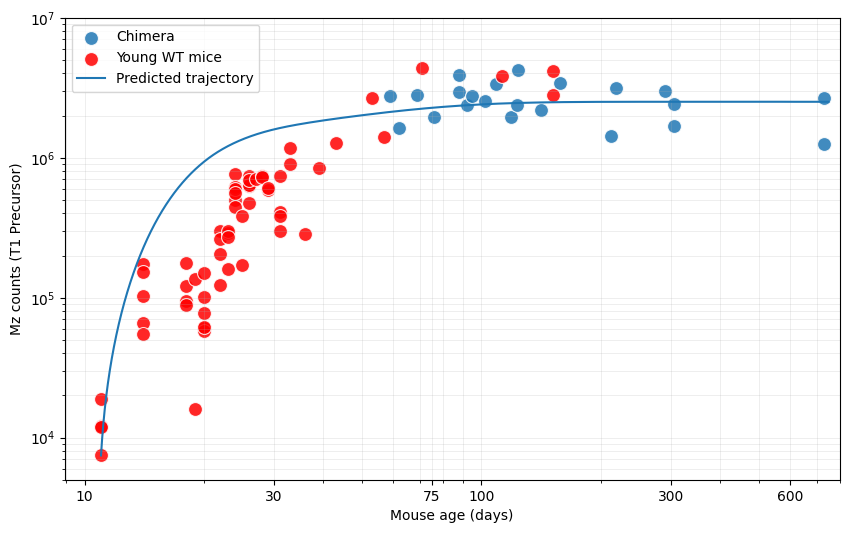

In [13]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()



/tmp/ipykernel_3498136/903803704.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


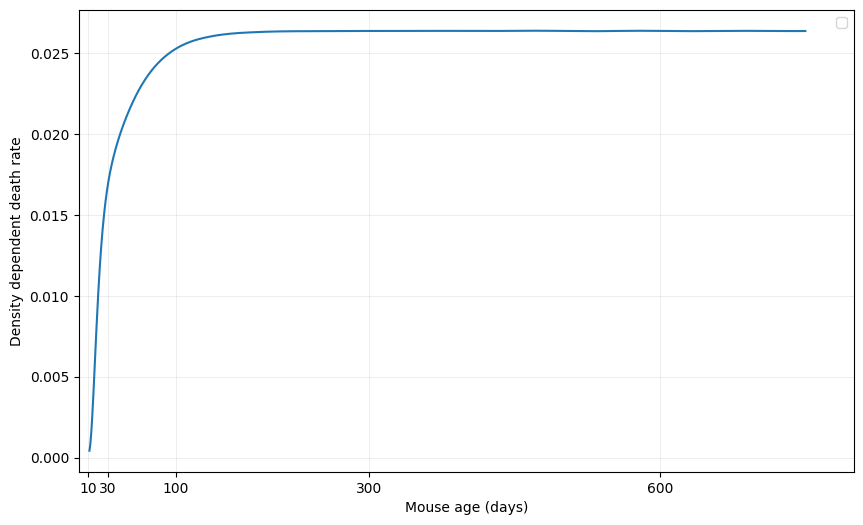

In [14]:
# Plot delta_dd

fig = plt.figure(figsize=(10, 6))
plt.plot(t_ev, delta_dd(sol.y[0]))
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0, 800)
plt.xticks([10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Density dependent death rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [15]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def delta_dd(M):
    delta = 0.00035
    size = 4e4
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

phi = 0.014 #Influx rate
rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 160, 0.001)


sol_1 = solve_ivp(ode_function, [11, 160], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)
print(np.mean(data_neutral.delta))
print(np.mean(data_neutral.size_dens))

[[  12058.           12092.82940721   12127.68391239 ... 2890782.44600569
  2890783.19496991 2890783.94391084]]
0.00034548063786999994
33291.814297


/tmp/ipykernel_3498136/2534866978.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


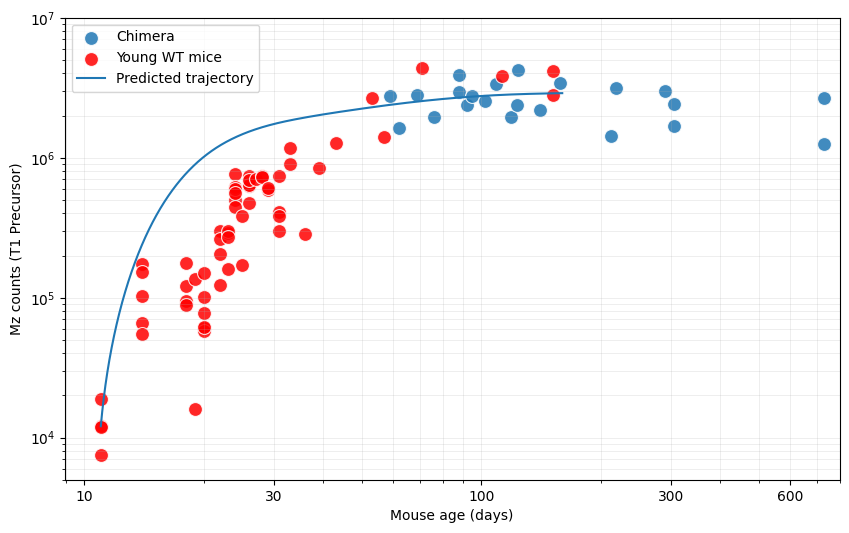

In [16]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [17]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def delta_dd(M):
    delta = 0.009
    size = 33292
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

phi = 0.014 #Influx rate
rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 160, 0.001)


sol_1 = solve_ivp(ode_function, [11, 160], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)

[[ 12058.          12092.68681142  12127.39819848 ... 290883.10156521
  290883.09289394 290883.08421305]]


/tmp/ipykernel_3498136/2534866978.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


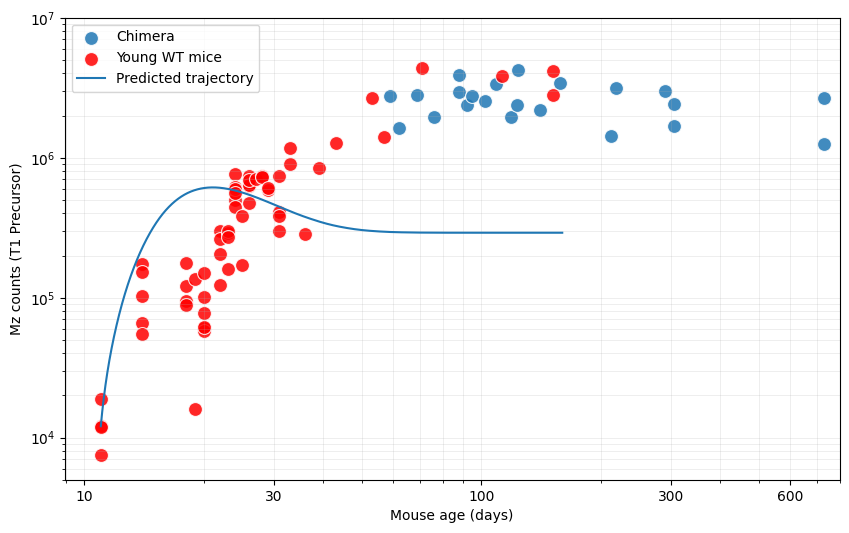

In [18]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.29
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = 0.25
    phi = 0.013
    # phi_var =  ((phi - 0.0019) / (1 + np.exp(-(r_phi) * (t-20)))) +0.0019
    phi_var =  phi / (1 + np.exp(-(r_phi) * (t-23)))
    return phi_var

def delta_dd(M):
    delta = np.mean(data_neutral.delta)
    size = np.mean(data_neutral.size_dens)
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi(t) * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

# def phi(t):
#     if(t < 40):
#     #  r_phi = 0.02
#     #  phi = 0.014
#     #  phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.7))
#      r_phi = 0.02
#      phi = 0.014
#      phi_var =  phi / (1 + np.exp(-(r_phi) * (t-10)))
#     return(phi_var)


rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)


sol_1 = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)
print(np.mean(data_neutral.delta))
print(np.mean(data_neutral.size_dens))

[[  12058.           12059.6856996    12061.37291185 ... 2481743.77845167
  2481743.78669936 2481743.79494843]]
0.00034548063786999994
33291.814297


/tmp/ipykernel_3498136/2960672019.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


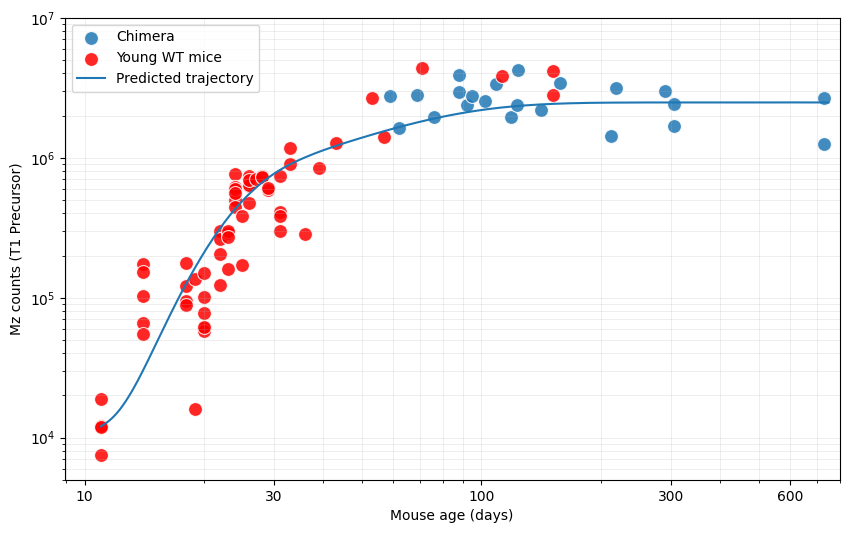

In [43]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


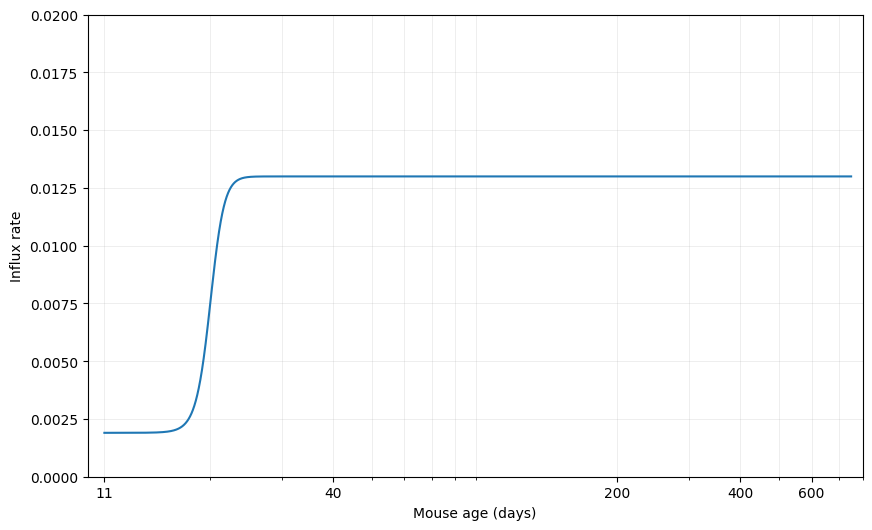

In [21]:
#Daily Influx from T1 TO Mz
# Plot phi(t)

fig = plt.figure(figsize=(10, 6))
plt.plot(t_ev, phi(t_ev))
plt.xscale('log')
# plt.yscale('log')
plt.xlim(10, 800)
plt.ylim(0, 0.02)
plt.xticks([11, 40, 200, 400, 600], [11, 40, 200, 400, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Influx rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

